### 1. simple CNN
### 2. LSTM
### 3. GRU
### 4. CNN + LSTM
### 5. CNN + GRU
### 6. ResNet
### 7. ResNet + transformer

In [2]:
import numpy as np
import pandas as pd
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
import seaborn as sns



def load_file(filepath):
    dataframe = pd.read_csv(filepath, header=None, delim_whitespace=True)
    return dataframe.values

# load a list of files and return as a 3d numpy array
def load_group(filenames, prefix=''):
    loaded = list()
    for name in filenames:
        data = load_file(prefix + name)
        loaded.append(data)
    # stack group so that features are the 3rd dimension
    loaded = np.dstack(loaded)
    return loaded

# load a dataset group, such as train or test
def load_dataset_group(group, prefix=''):
    filepath = prefix + group + '/Inertial Signals/'
    # load all 9 files as a single array
    filenames = list()
    # total acceleration
    filenames += ['total_acc_x_'+group+'.txt', 'total_acc_y_'+group+'.txt', 'total_acc_z_'+group+'.txt']
    # body acceleration
    filenames += ['body_acc_x_'+group+'.txt', 'body_acc_y_'+group+'.txt', 'body_acc_z_'+group+'.txt']
    # body gyroscope
    filenames += ['body_gyro_x_'+group+'.txt', 'body_gyro_y_'+group+'.txt', 'body_gyro_z_'+group+'.txt']
    # load input data
    X = load_group(filenames, filepath)
    # load class output
    y = load_file(prefix + group + '/y_'+group+'.txt')
    return X, y


# load the dataset, returns train and test X and y elements
# load the dataset, returns train and test X and y elements
def load_dataset(prefix=''):

    # === 경로 수정 ===
    # 알려주신 Colab 경로로 기본 경로를 수정합니다.
    base_path = '/content/drive/MyDrive/Colab Notebooks/ML/UCI-HAR/'

    # load all train
    trainX, trainy = load_dataset_group('train', prefix + base_path)
    # load all test
    testX, testy = load_dataset_group('test', prefix + base_path)
    # === 경로 수정 완료 ===

    #zero-offset class values
    trainy = trainy - 1
    testy = testy - 1
    #one hot encode y
    trainy_one_hot = to_categorical(trainy)
    testy_one_hot = to_categorical(testy)
    print("trainX shape:", trainX.shape)
    print("trainy shape:", trainy.shape)
    print("trainy_one_hot shape:", trainy_one_hot.shape)
    print("testX shape:", testX.shape)
    print("testy shape:", testy.shape)
    print("testy_one_hot shape:", testy_one_hot.shape)
    return trainX, trainy, trainy_one_hot, testX, testy, testy_one_hot

# --- 이 함수를 다시 호출하여 데이터를 로드합니다 ---
trainX, trainy, trainy_one_hot, testX, testy, testy_one_hot = load_dataset()

# --- 데이터 분할 (기존 코드와 동일) ---
from sklearn.model_selection import train_test_split

X_train,X_val,y_train_one_hot,y_val_one_hot,y_train,y_val=train_test_split(trainX, trainy_one_hot, trainy,test_size=0.2,random_state=100)

print("\n--- 분할 후 데이터 Shape ---")
print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("y_train_one_hot shape:", y_train_one_hot.shape)
print("y_val_one_hot shape:", y_val_one_hot.shape)

/tmp/ipython-input-3873133836.py:10: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  dataframe = pd.read_csv(filepath, header=None, delim_whitespace=True)
/tmp/ipython-input-3873133836.py:10: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  dataframe = pd.read_csv(filepath, header=None, delim_whitespace=True)
/tmp/ipython-input-3873133836.py:10: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  dataframe = pd.read_csv(filepath, header=None, delim_whitespace=True)
/tmp/ipython-input-3873133836.py:10: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  dataframe = pd.read_csv(filepath, header=None, delim_whitespace=Tr

trainX shape: (7352, 128, 9)
trainy shape: (7352, 1)
trainy_one_hot shape: (7352, 6)
testX shape: (2947, 128, 9)
testy shape: (2947, 1)
testy_one_hot shape: (2947, 6)

--- 분할 후 데이터 Shape ---
X_train shape: (5881, 128, 9)
X_val shape: (1471, 128, 9)
y_train_one_hot shape: (5881, 6)
y_val_one_hot shape: (1471, 6)


In [3]:
n_timesteps, n_features, n_outputs = X_train.shape[1], X_train.shape[2], y_train_one_hot.shape[1]

In [4]:
import tensorflow as tf
from tensorflow.keras import models, layers

# 1. 모델 구성 (Simple CNN)
# -----------------------------
# n_timesteps, n_features, n_outputs 변수는 이전에 정의됨
# (n_timesteps=128, n_features=9, n_outputs=6)

model_complex_cnn = models.Sequential([
    # --- 블록 1 ---
    layers.Conv1D(filters=64, kernel_size=3, activation='relu',
                  input_shape=(n_timesteps, n_features),
                  padding='same'), # 'same' 패딩으로 길이 유지
    layers.BatchNormalization(), # 배치 정규화 추가

    # --- 블록 2 (새로 추가) ---
    layers.Conv1D(filters=128, kernel_size=5, activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling1D(pool_size=2), # 여기서 한 번 풀링

    # --- 블록 3 (새로 추가) ---
    layers.Conv1D(filters=256, kernel_size=7, activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling1D(pool_size=2), # 여기서 또 한 번 풀링

    # --- 분류기 (Classifier) ---
    layers.Flatten(),

    # Dense 층 강화
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),

    # (선택) Dense 층 하나 더 추가
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.5),

    # 출력층 (동일)
    layers.Dense(n_outputs, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [5]:
# 2. 모델 컴파일
# -----------------------------
# y_train_one_hot을 사용하므로, loss는 'categorical_crossentropy'를 사용합니다.
model_complex_cnn.compile(optimizer='adam',
                loss='categorical_crossentropy',
                metrics=['accuracy'])

# 모델 구조 요약
model_complex_cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 128, 64)        │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 128, 128)       │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 64, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 64, 256)        │       229,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 32, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       524,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           198 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 800,934 (3.06 MB)

 Trainable params: 800,038 (3.05 MB)

 Non-trainable params: 896 (3.50 KB)

In [6]:
# 3. 모델 학습
# -----------------------------
# X_val, y_val_one_hot으로 검증 데이터를 사용합니다.
epochs = 30
batch_size = 64

history_1 = model_complex_cnn.fit(X_train, y_train_one_hot,
                      epochs=epochs,
                      batch_size=batch_size,
                      validation_data=(X_val, y_val_one_hot),
                      verbose=1)

Epoch 1/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 22s 205ms/step - accuracy: 0.4627 - loss: 2.2185 - val_accuracy: 0.3215 - val_loss: 2.7478
Epoch 2/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 19s 210ms/step - accuracy: 0.7107 - loss: 0.8265 - val_accuracy: 0.5751 - val_loss: 1.9363
Epoch 3/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 18s 201ms/step - accuracy: 0.8219 - loss: 0.5476 - val_accuracy: 0.7172 - val_loss: 0.8644
Epoch 4/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 19s 183ms/step - accuracy: 0.8623 - loss: 0.4042 - val_accuracy: 0.8545 - val_loss: 0.5212
Epoch 5/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 17s 186ms/step - accuracy: 0.8630 - loss: 0.3793 - val_accuracy: 0.9109 - val_loss: 0.2131
Epoch 6/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 18s 197ms/step - accuracy: 0.8833 - loss: 0.3260 - val_accuracy: 0.9395 - val_loss: 0.1219
Epoch 7/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 17s 188ms/step - accuracy: 0.8957 - loss: 0.2669 - val_accuracy: 0.9320 - val_loss: 0.1310
Epoch 8/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 21s 199ms/step - accuracy: 0.9080 - loss: 0.2304 - val_accu

In [7]:
# 4. 모델 평가 (Test set)
# -----------------------------
# 학습에 사용하지 않은 'testX', 'testy_one_hot'으로 최종 평가
print("\n--- 1. CNN 모델 테스트 평가 ---")
test_loss_1, test_acc_1 = model_complex_cnn.evaluate(testX, testy_one_hot, verbose=2)
print(f"\nTest Accuracy (CNN): {test_acc_1*100:.2f}%")


--- 1. CNN 모델 테스트 평가 ---
93/93 - 2s - 20ms/step - accuracy: 0.9192 - loss: 0.4171

Test Accuracy (CNN): 91.92%


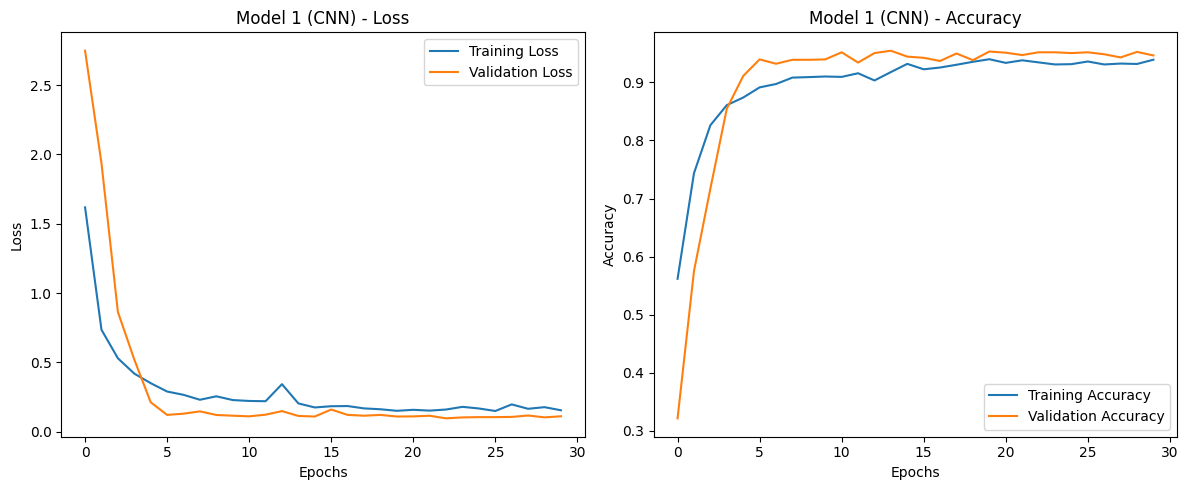

In [8]:
# 5. 학습 과정 시각화
# -----------------------------
plt.figure(figsize=(12, 5))

# 손실(Loss) 그래프
plt.subplot(1, 2, 1)
plt.plot(history_1.history['loss'], label='Training Loss')
plt.plot(history_1.history['val_loss'], label='Validation Loss')
plt.title('Model 1 (CNN) - Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# 정확도(Accuracy) 그래프
plt.subplot(1, 2, 2)
plt.plot(history_1.history['accuracy'], label='Training Accuracy')
plt.plot(history_1.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model 1 (CNN) - Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()